# Compare CRDM and DMC

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from itertools import product
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from confrdm.simulators.dmc import simulate_dmc
from confrdm.simulators.rdmc import simulate_rdmc_two_accumulators


In [3]:
NUM_OBS = 10_000
T_MAX = 5000

In [4]:
def simulate_crdm_conditions(s_false=1.0, a_shape=2.0, **kwargs):
    v_c_congruent = kwargs.pop("v_c_slope_congruent")
    v_c_incongruent = kwargs.pop("v_c_slope_incongruent")
    s_congruent = kwargs.pop("s_true_congruent")
    s_incongruent = kwargs.pop("s_true_incongruent")

    amp = kwargs.pop("amp")

    data_congruent = simulate_rdmc_two_accumulators(
        v_c_slope=v_c_congruent,
        s_true=s_congruent,
        amp=amp,
        s_false=s_false,
        a_shape=a_shape,
        num_obs=NUM_OBS // 2,
        t_max=T_MAX,
        **kwargs,
    )

    data_incongruent = simulate_rdmc_two_accumulators(
        v_c_slope=v_c_incongruent,
        s_true=s_incongruent,
        amp=-amp,
        num_obs=NUM_OBS // 2,
        s_false=s_false,
        a_shape=a_shape,
        t_max=T_MAX,
        **kwargs,
    )

    condition = np.repeat([1, 0], data_congruent["x"].shape[0])

    return np.c_[np.vstack([data_congruent["x"], data_incongruent["x"]]), condition]


def simulate_dmc_conditions(a_shape=2.0, alpha=0.0, s=1.0, **kwargs):
    v_c_congruent = kwargs.pop("v_c_congruent")
    v_c_incongruent = kwargs.pop("v_c_incongruent")

    amp = kwargs.pop("amp")

    data_congruent = simulate_dmc(
        v_c=v_c_congruent,
        amp=amp,
        s=s,
        alpha=alpha,
        a_shape=a_shape,
        num_obs=NUM_OBS // 2,
        t_max=T_MAX,
        **kwargs,
    )

    data_incongruent = simulate_dmc(
        v_c=v_c_incongruent,
        amp=-amp,
        s=s,
        alpha=alpha,
        a_shape=a_shape,
        num_obs=NUM_OBS // 2,
        t_max=T_MAX,
        **kwargs,
    )

    condition = np.repeat([1, 0], data_congruent["x"].shape[0])

    return np.c_[np.vstack([data_congruent["x"], data_incongruent["x"]]), condition]

In [5]:
def create_delta_plot(data, ax):
    rt = data[:, 0]
    resp = data[:, 1]
    cond = data[:, 2]

    qs = np.linspace(0, 1, 9)[1:-1]

    mean_quantiles = np.array(
        [
            stats.mstats.mquantiles(
                rt[np.bitwise_and(resp == 1, cond == i)],
                qs,
                alphap=0.5,
                betap=0.5,
            )
            for i in (0, 1)
        ],
    )

    diff_quantiles = mean_quantiles[0, :] - mean_quantiles[1, :]

    ax.plot(mean_quantiles.mean(axis=0), diff_quantiles, "--o", color="black")

    return ax


def create_caf_plot(data, ax, n_bins=5):
    rt = data[:, 0]
    resp = data[:, 1]
    cond = data[:, 2]

    color_dict = {
        0: "maroon",
        1: "darkgreen",
    }

    for i in np.unique(cond):
        # Select data for this condition
        mask = cond == i
        rt_cond = rt[mask]
        resp_cond = resp[mask]
        # Bin RTs for this condition
        bins = np.quantile(rt_cond, np.linspace(0, 1, n_bins + 1))
        bin_indices = np.digitize(rt_cond, bins, right=True) - 1
        # Ensure bin_indices are within range
        bin_indices = np.clip(bin_indices, 0, n_bins - 1)
        prop_resp = []
        bin_centers = []
        for b in range(n_bins):
            in_bin = bin_indices == b
            if np.any(in_bin):
                prop = resp_cond[in_bin].mean()
                center = rt_cond[in_bin].mean()
            else:
                prop = np.nan
                center = np.nan
            prop_resp.append(prop)
            bin_centers.append(center)
        ax.plot(range(1, n_bins + 1), prop_resp, marker="o", linestyle="-", color=color_dict[i])

    return ax


def create_delta_caf_plot(data, n_bins=5):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    for x in data:
        ax1 = create_delta_plot(x, ax1)
        ax2 = create_caf_plot(x, ax2, n_bins)

    ax1.set_ylabel("Difference mean RT congruent vs. incongruent (ms)")
    ax1.set_xlabel("Mean RT quantiles (ms)")

    ax2.set_xlabel("RT bin")
    ax2.set_ylabel("Accuracy")
    ax2.set_ylim(0, 1)
    ax2.spines["bottom"].set_position("zero")
    ax2.set_xticks(range(1, n_bins + 1))
    ax2.set_yticks([0, 0.5, 1])

    fig.tight_layout()

    return fig, (ax1, ax2)



# Manipulate amplitude

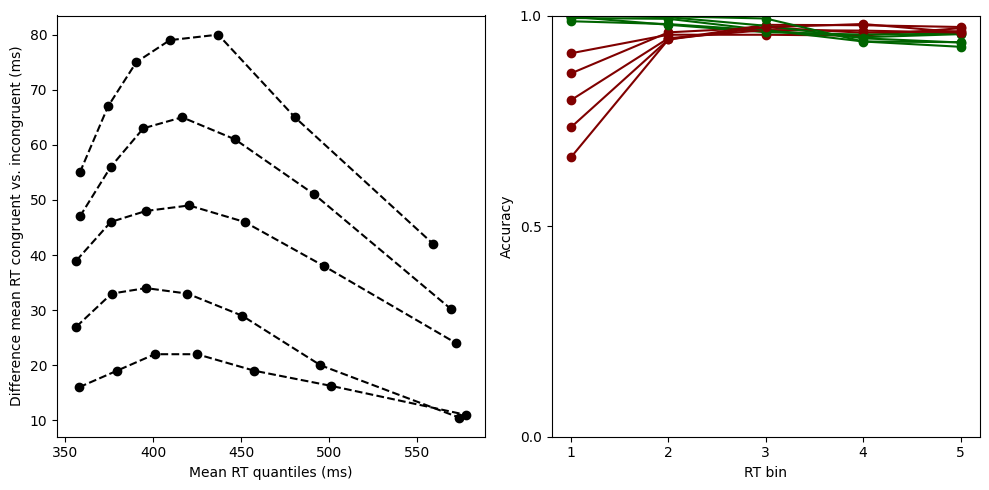

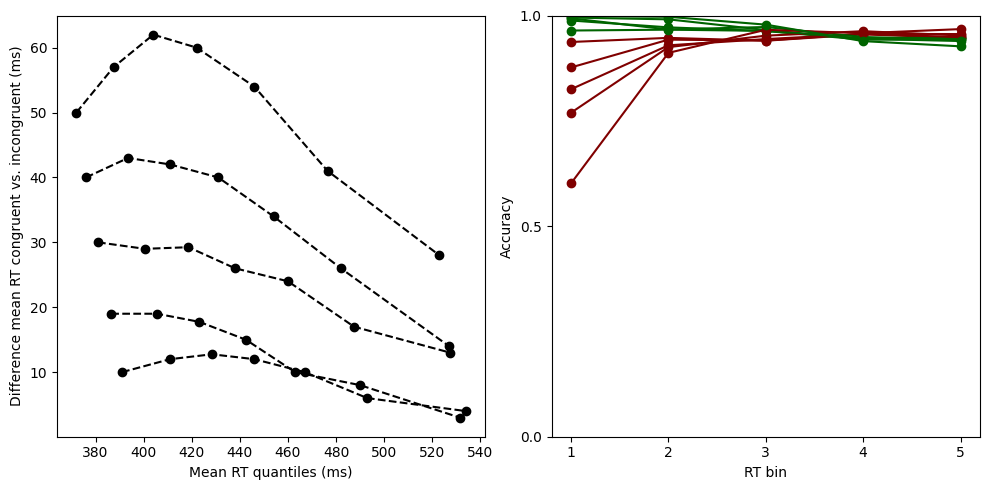

In [25]:
v_c_dmc = 3.0
b_dmc = 0.5
s_dmc = 1.0

v_intercept_crdm = 0.5
v_c_slope_crdm = 5.0
s_true_crdm = 0.9
b_crdm = 0.9

t0 = 0.3

dmc_params = dict(
    v_c_congruent=v_c_dmc,
    v_c_incongruent=v_c_dmc,
    b=b_dmc,
    t0=t0,
    s=s_dmc,
)

crdm_params = dict(
    v_c_intercept=v_intercept_crdm,
    v_c_slope_congruent=v_c_slope_crdm,
    v_c_slope_incongruent=v_c_slope_crdm,
    s_true_congruent=s_true_crdm,
    s_true_incongruent=s_true_crdm,
    b=b_crdm,
    t0=t0,
)

amp_arr = np.linspace(0.05, 0.2, 5)
tau_arr = [0.05]

product_iter = product(amp_arr, tau_arr)

dmc_data = []
crdm_data = []

for p in product_iter:
    dmc_data.append(simulate_dmc_conditions(amp=p[0], tau=p[1], **dmc_params))
    crdm_data.append(simulate_crdm_conditions(amp=2 * p[0], tau=p[1], **crdm_params))

dmc_data = np.array(dmc_data)
crdm_data = np.array(crdm_data)

_ = create_delta_caf_plot(dmc_data)
_ = create_delta_caf_plot(crdm_data)


In [7]:
def create_pushforward_plot(data):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 5))
    rt = data[:, 0]
    resp = data[:, 1]
    cond = data[:, 2]

    for i, ax in enumerate((ax1, ax2)):
        sns.histplot(
            rt[np.bitwise_and(resp == 1, cond == i)], color="darkgreen", alpha=0.5, ax=ax,
        )

        ax.text(
            0.9,
            0.9,
            f"Acc: {np.round(resp[cond == i].mean(), 2)!s}",
            horizontalalignment="center",
            verticalalignment="center",
            transform=ax.transAxes,
        )

        ax.spines["bottom"].set_position("zero")

        ax.set_ylabel("")
        ax.set_yticks([])
        ax.set_xlabel("Simulated RTs (milliseconds)")

    ax1.set_title("Incongruent")
    ax2.set_title("Congruent")

    fig.tight_layout()

    return fig, (ax1, ax2)

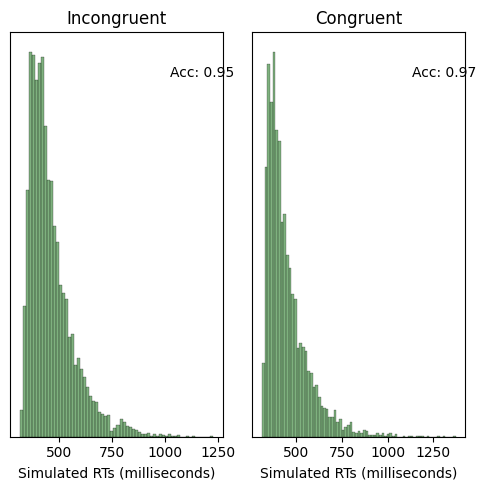

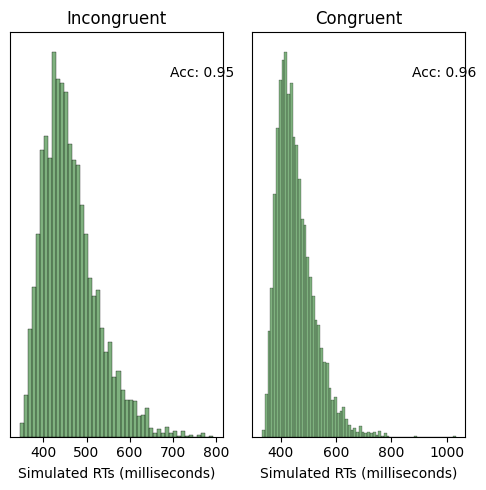

In [26]:
_ = create_pushforward_plot(dmc_data[0])
_ = create_pushforward_plot(crdm_data[0])

## Manipulate tau

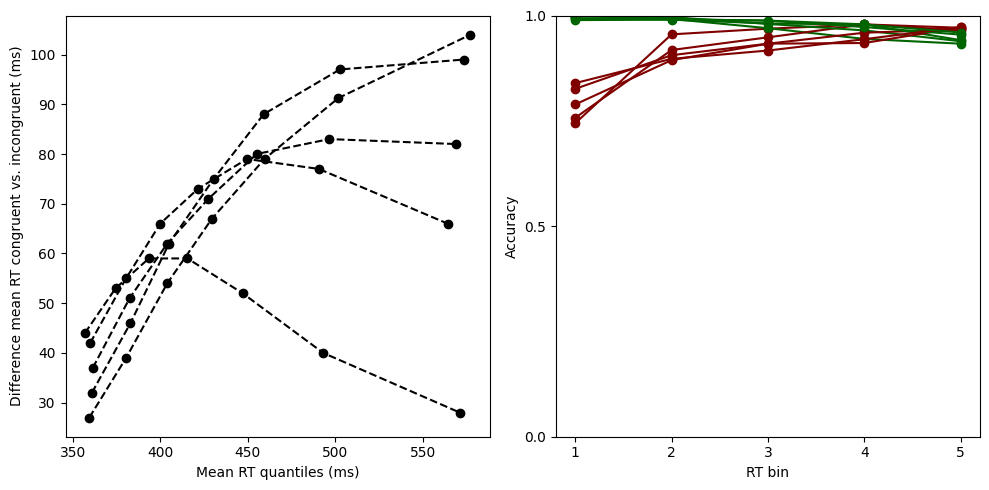

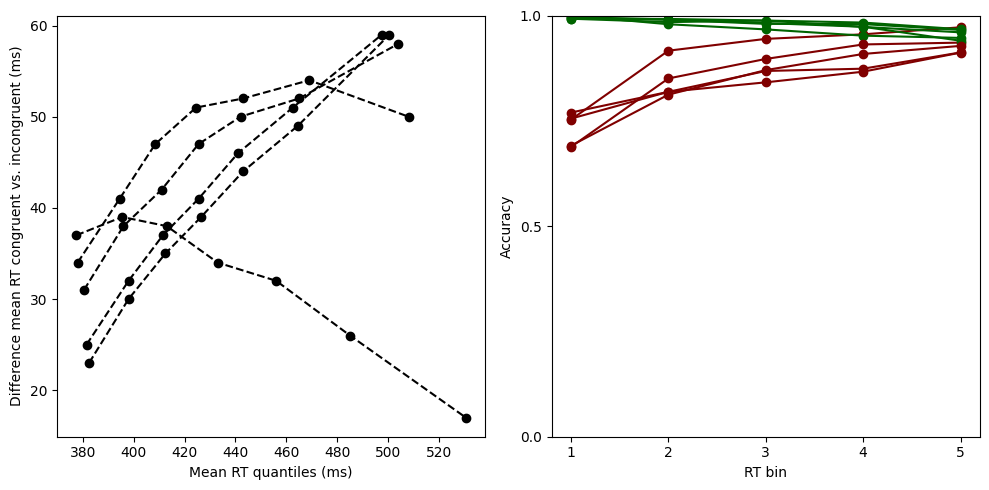

In [27]:
amp_arr = [0.15]
tau_arr = np.linspace(0.05, 0.2, 5)
# a_shape_arr = np.linspace(2, 5, 3)

product_iter = product(amp_arr, tau_arr)

dmc_data = []
crdm_data = []

for p in product_iter:
    dmc_data.append(simulate_dmc_conditions(amp=p[0], tau=p[1], **dmc_params))
    crdm_data.append(simulate_crdm_conditions(amp=2 * p[0], tau=p[1], **crdm_params))

dmc_data = np.array(dmc_data)
crdm_data = np.array(crdm_data)

_ = create_delta_caf_plot(dmc_data)
_ = create_delta_caf_plot(crdm_data)

## Manipulate shape

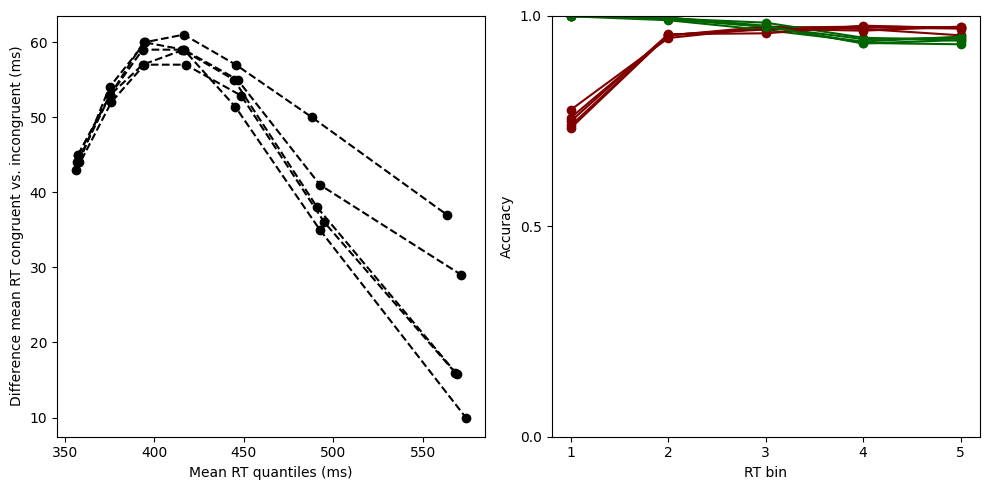

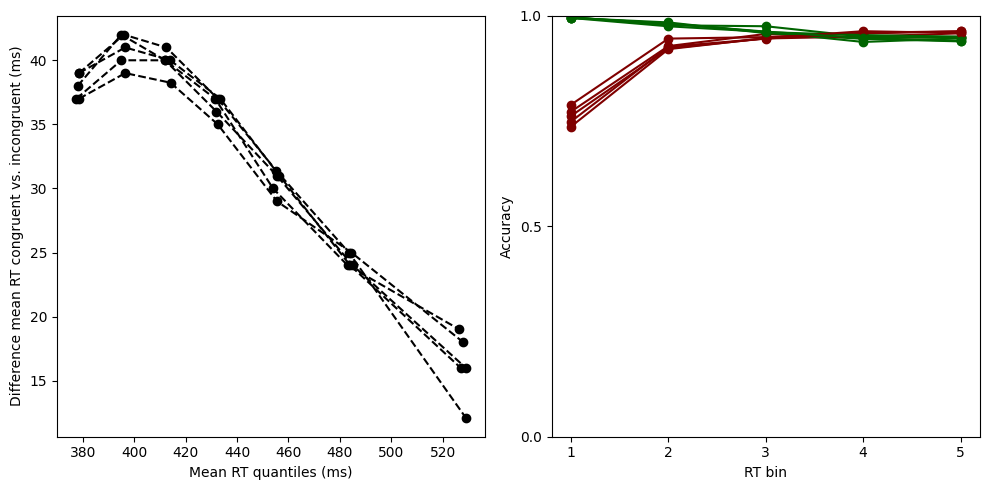

In [28]:
amp_arr = [0.15]
tau_arr = [0.05]
a_shape_arr = np.linspace(2, 2, 5)

product_iter = product(amp_arr, tau_arr, a_shape_arr)

dmc_data = []
crdm_data = []

for p in product_iter:
    dmc_data.append(simulate_dmc_conditions(amp=p[0], tau=p[1], a_shape=p[2], **dmc_params))
    crdm_data.append(simulate_crdm_conditions(amp=2 * p[0], tau=p[1], a_shape=p[2], **crdm_params))

dmc_data = np.array(dmc_data)
crdm_data = np.array(crdm_data)

_ = create_delta_caf_plot(dmc_data)
_ = create_delta_caf_plot(crdm_data)